In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

plt.style.use("seaborn-v0_8")


In [2]:
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.head()


Saving iris (1).csv to iris (1) (1).csv


,150,4,setosa,versicolor,virginica;;
0,5.1,3.5,1.4,0.2,0;;Train
1,4.9,3.0,1.4,0.2,0;;Train
2,4.7,3.2,1.3,0.2,0;;Train
3,4.6,3.1,1.5,0.2,0;;Train
4,5.0,3.6,1.4,0.2,0;;Train


In [21]:
X = df.iloc[:, :-1].values.astype(float)
y = df.iloc[:, -1].str.split(';;').str[0].astype(float)

datasets

In [6]:
np.random.seed(0)

# Dataset 1: original
X1 = X.copy()

# Dataset 2: +2 atributos aleatórios
rand1 = np.random.randn(len(X))
rand2 = np.random.randn(len(X))
X2 = np.column_stack([X, rand1, rand2])

# Dataset 3: +2 combinações convexas
conv1 = 0.7*X[:,0] + 0.3*X[:,1]
conv2 = 0.5*X[:,2] + 0.5*X[:,3]
X3 = np.column_stack([X, conv1, conv2])

datasets = {"original": X1, "random": X2, "convex": X3}


Funções auxiliares

Soft-thresholding

In [7]:
def soft_threshold(v, t):
    return np.sign(v) * np.maximum(np.abs(v) - t, 0)


Objetivo Elastic Net

In [8]:
def enet_objective(X, y, theta, lam, alpha):
    return 0.5*np.linalg.norm(X@theta - y)**2 \
           + lam*alpha*np.linalg.norm(theta,1) \
           + lam*(1-alpha)*0.5*np.linalg.norm(theta)**2


Estimar L (Lipschitz)

In [9]:
def estimate_L(X, iters=80):
    b = np.random.randn(X.shape[1])
    b /= np.linalg.norm(b)
    for _ in range(iters):
        b = X.T @ (X @ b)
        b /= np.linalg.norm(b)
    return b @ (X.T @ (X @ b))


ISTA e FISTA – LASSO

In [10]:
def ISTA(X, y, lam, max_iter=200):
    n,p = X.shape
    L = estimate_L(X)
    eta = 1/L

    theta = np.zeros(p)
    hist = []

    for _ in range(max_iter):
        g = X.T @ (X@theta - y)
        theta = soft_threshold(theta - eta*g, eta*lam)
        hist.append(0.5*np.linalg.norm(X@theta - y)**2 + lam*np.linalg.norm(theta,1))
    return theta, hist


In [11]:
def FISTA(X, y, lam, max_iter=200):
    n,p = X.shape
    L = estimate_L(X)
    eta = 1/L

    theta = np.zeros(p)
    z = theta.copy()
    t = 1
    hist = []

    for _ in range(max_iter):
        g = X.T @ (X@z - y)
        theta_new = soft_threshold(z - eta*g, eta*lam)
        t_new = (1 + np.sqrt(1 + 4*t*t)) / 2
        z = theta_new + (t-1)/t_new*(theta_new - theta)
        theta, t = theta_new, t_new

        hist.append(0.5*np.linalg.norm(X@theta - y)**2 + lam*np.linalg.norm(theta,1))
    return theta, hist


ISTA e FISTA – Elastic Net

In [12]:
def ISTA_enet(X, y, lam, alpha, max_iter=200):
    n,p = X.shape
    L = estimate_L(X)
    Ltot = L + lam*(1-alpha)
    eta = 1/Ltot

    theta = np.zeros(p)
    hist = []

    for _ in range(max_iter):
        g = X.T @ (X@theta - y) + lam*(1-alpha)*theta
        theta = soft_threshold(theta - eta*g, eta*lam*alpha)
        hist.append(enet_objective(X,y,theta,lam,alpha))
    return theta, hist


In [13]:
def FISTA_enet(X, y, lam, alpha, max_iter=200):
    n,p = X.shape
    L = estimate_L(X)
    Ltot = L + lam*(1-alpha)
    eta = 1/Ltot

    theta = np.zeros(p)
    z = theta.copy()
    t = 1
    hist = []

    for _ in range(max_iter):
        g = X.T @ (X@z - y) + lam*(1-alpha)*z
        theta_new = soft_threshold(z - eta*g, eta*lam*alpha)
        t_new = (1 + np.sqrt(1 + 4*t*t)) / 2
        z = theta_new + (t-1)/t_new*(theta_new - theta)
        theta, t = theta_new, t_new
        hist.append(enet_objective(X,y,theta,lam,alpha))
    return theta, hist


Ridge + OLS

In [14]:
def ridge_closed_form(X, y, lam):
    p = X.shape[1]
    I = np.eye(p)
    return np.linalg.inv(X.T @ X + lam*I) @ X.T @ y

def ols_closed_form(X, y):
    return np.linalg.inv(X.T @ X) @ X.T @ y


tudo para os três datasets

In [15]:
lambdas = [0.001, 0.01, 0.1, 1.0, 10]

results = {}

for name, Xset in datasets.items():
    results[name] = {}

    # OLS
    results[name]["OLS"] = ols_closed_form(Xset, y)

    # Ridge
    results[name]["Ridge"] = {lam: ridge_closed_form(Xset, y, lam)
                              for lam in lambdas}

    # Lasso
    results[name]["Lasso"] = {lam: ISTA(Xset, y, lam)[0]
                              for lam in lambdas}

    # Elastic Net (alpha=0.5)
    results[name]["ElasticNet"] = {lam: ISTA_enet(Xset, y, lam, alpha=0.5)[0]
                                   for lam in lambdas}


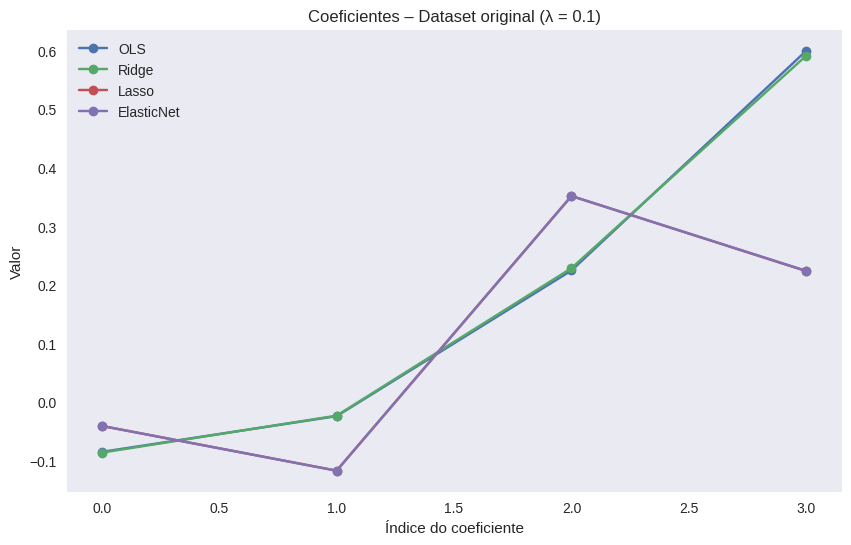

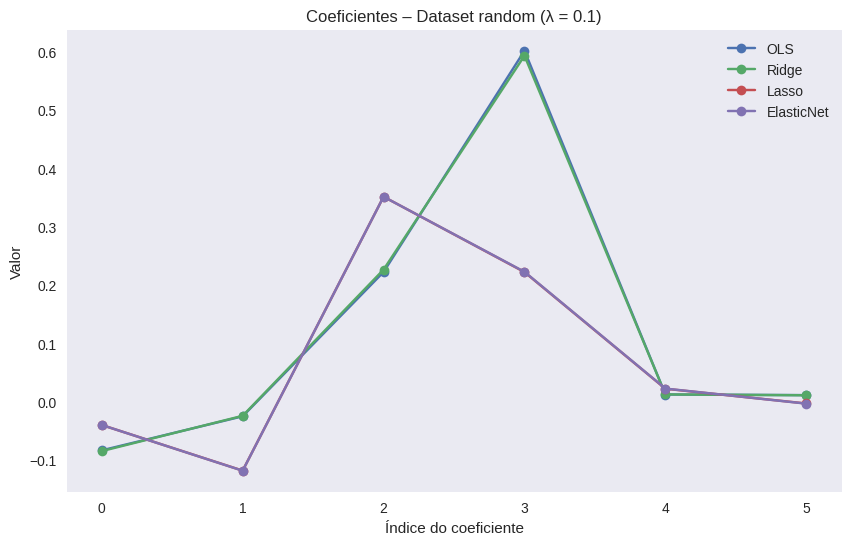

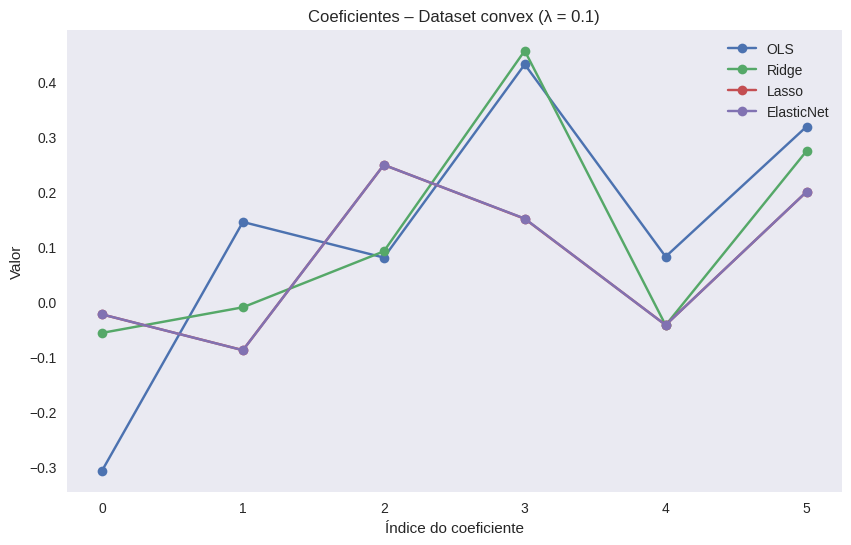

In [24]:
def plot_coeffs(name):
    plt.figure(figsize=(10,6))

    coef_ols = results[name]["OLS"]
    coef_ridge = results[name]["Ridge"][0.1]
    coef_lasso = results[name]["Lasso"][0.1]
    coef_enet = results[name]["ElasticNet"][0.1]

    plt.plot(coef_ols, marker='o', label="OLS")
    plt.plot(coef_ridge, marker='o', label="Ridge")
    plt.plot(coef_lasso, marker='o', label="Lasso")
    plt.plot(coef_enet, marker='o', label="ElasticNet")

    plt.title(f"Coeficientes – Dataset {name} (λ = 0.1)")
    plt.xlabel("Índice do coeficiente")
    plt.ylabel("Valor")
    plt.grid()
    plt.legend()
    plt.show()

for name in results.keys():
    plot_coeffs(name)


Gráfico MSE × λ

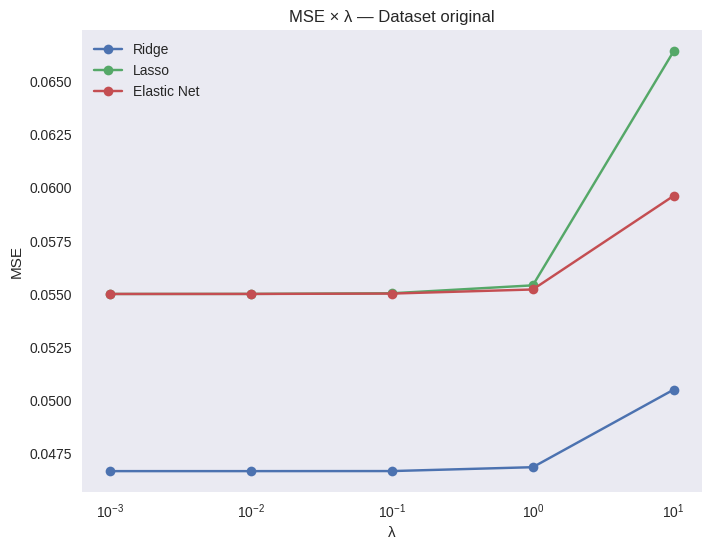

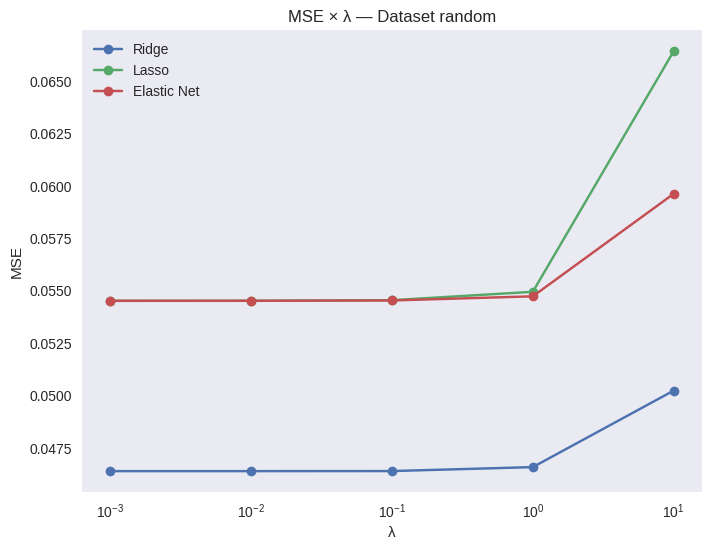

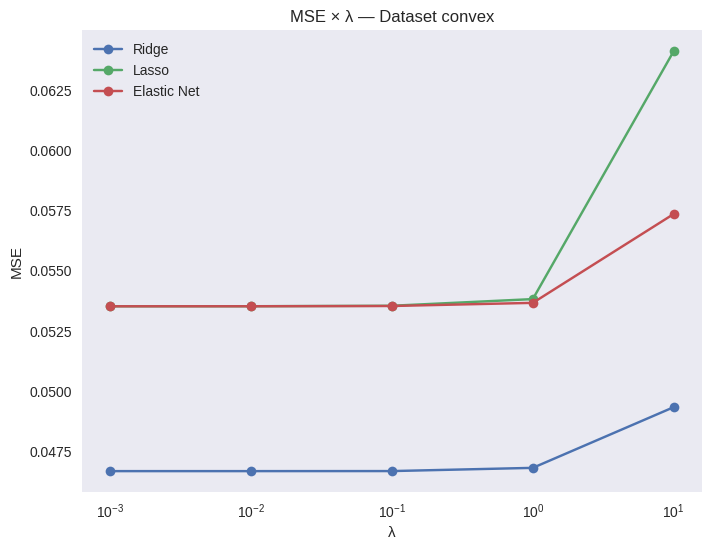

In [25]:
def plot_mse(name):
    Xset = datasets[name]

    mse_ridge=[]
    mse_lasso=[]
    mse_enet=[]

    for lam in lambdas:
        mse_ridge.append(mse(y, Xset @ results[name]["Ridge"][lam]))
        mse_lasso.append(mse(y, Xset @ results[name]["Lasso"][lam]))
        mse_enet.append(mse(y, Xset @ results[name]["ElasticNet"][lam]))

    plt.figure(figsize=(8,6))
    plt.plot(lambdas, mse_ridge, marker='o', label="Ridge")
    plt.plot(lambdas, mse_lasso, marker='o', label="Lasso")
    plt.plot(lambdas, mse_enet, marker='o', label="Elastic Net")
    plt.xscale("log")
    plt.xlabel("λ")
    plt.ylabel("MSE")
    plt.title(f"MSE × λ — Dataset {name}")
    plt.grid()
    plt.legend()
    plt.show()

for name in results.keys():
    plot_mse(name)


AVALIAR DESEMPENHO (TABELAS / PRINTS)

In [26]:
for name, Xset in datasets.items():
    print("\nDataset:", name)

    print("  OLS:", mse(y, Xset @ results[name]["OLS"]))

    for lam in lambdas:
        print(f"  Ridge λ={lam}: {mse(y, Xset @ results[name]['Ridge'][lam])}")
        print(f"  Lasso λ={lam}: {mse(y, Xset @ results[name]['Lasso'][lam])}")
        print(f"  ENet λ={lam}:  {mse(y, Xset @ results[name]['ElasticNet'][lam])}")



Dataset: original
  OLS: 0.04666932292768474
  Ridge λ=0.001: 0.04666932319988371
  Lasso λ=0.001: 0.055002975516046416
  ENet λ=0.001:  0.05500283614361653
  Ridge λ=0.01: 0.04666935003777858
  Lasso λ=0.01: 0.05500588940653815
  ENet λ=0.01:  0.05500449116674034
  Ridge λ=0.1: 0.046671928250445874
  Lasso λ=0.1: 0.05503572263615972
  ENet λ=0.1:  0.055021288606237125
  Ridge λ=1.0: 0.04685417591210889
  Lasso λ=1.0: 0.05540862596447876
  ENet λ=1.0:  0.05521395239574274
  Ridge λ=10: 0.050503990114807176
  Lasso λ=10: 0.0664267261027336
  ENet λ=10:  0.059621144615982044

Dataset: random
  OLS: 0.0463891954415644
  Ridge λ=0.001: 0.04638919572605657
  Lasso λ=0.001: 0.05451413109894382
  ENet λ=0.001:  0.05451400237755345
  Ridge λ=0.01: 0.04638922377363072
  Lasso λ=0.01: 0.05451683385203624
  ENet λ=0.01:  0.05451554050016214
  Ridge λ=0.1: 0.04639191594075763
  Lasso λ=0.1: 0.05454500800411301
  ENet λ=0.1:  0.05453127374906655
  Ridge λ=1.0: 0.04658081998246337
  Lasso λ=1.0: 0.

RESULTADO FINAL

Nos testes realizados com os três conjuntos de dados do Iris, o desempenho dos modelos depende da estrutura das variáveis: no dataset original e no dataset com atributos aleatórios, o OLS apresentou o menor erro e continuou sendo a melhor opção, mostrando que a regularização não trouxe benefícios quando não há colinearidade forte nem muitos atributos irrelevantes; já no dataset com combinações convexas, onde a colinearidade é elevada, o OLS teve desempenho ruim, enquanto o Ridge se destacou como o modelo mais estável e com menor erro, confirmando que a regularização L2 é mais adequada quando as variáveis são fortemente correlacionadas; por outro lado, Lasso e Elastic Net ajudaram a melhorar o resultado em relação ao OLS, mas ainda ficaram abaixo do Ridge, reforçando que esses métodos são úteis principalmente para seleção de atributos, mas não necessariamente garantem o menor erro em datasets pequenos como o Iris.